#820_Pet_Cats_in_the_UK_M3_Integrated

---



**Section B Team 12**

**Group Member; Kaixin Gao, Kang Ni, Xiaoyan Wang, Fei Han**

##Dataset Selection & Understanding

##Domain & Context

The Pet Cats UK dataset comes from the Movebank for Animal Tracking Data and contains high-resolution GPS tracking and metadata for domestic cats in the United Kingdom between 2013 and 2017. Cats were fitted with GPS collars, generating time-stamped location pings that capture fine-grained living habit within and beyond home environments. In addition to spatial trajectories, the dataset includes cat-level characteristics such as age, sex, neuter status, and hunting behavior.

###Motivation

Pet cats are widely distributed across urban areas, yet their living habit is often treated as homogeneous despite growing evidence of substantial individual variation. Analysis of the Pet Cats UK dataset shows that while most cats remain close to their homes, a small subset exhibits irregular living habit. Understanding these differences is important because cats’ movement behaviors directly influence ecological impacts, exposure to risk, and interactions with humans and the urban environment. By identifying distinct movement patterns among urban pet cats, this project aims to support more targeted and evidence-based decision-making for conservation groups, policymakers, and pet owners.

###Stakeholders & Decision-Makers



*   Urban planners and local councils
*   veterinarian

*   Pet owner

*  Urban biodiversity–focused conservation organizations
*   Ecologist






###Data Insights

###Data Import and Preparation

In [ ]:
import pandas as pd
import numpy as np

cats_gps_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk.csv"
cats_meta_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk_reference.csv"
cats_gps = pd.read_csv(cats_gps_url)
cats_meta = pd.read_csv(cats_meta_url)
print("GPS dataset shape:", cats_gps.shape)
print("Metadata dataset shape:", cats_meta.shape)

cats_gps.head(), cats_meta.head()

GPS dataset shape: (18215, 11)
Metadata dataset shape: (101, 16)


(  tag_id    event_id  visible             timestamp  location_long  \
 0   Ares  3395610551     True  2017-06-24T01:03:57Z      -5.113851   
 1   Ares  3395610552     True  2017-06-24T01:11:20Z      -5.113851   
 2   Ares  3395610553     True  2017-06-24T02:58:16Z      -5.113730   
 3   Ares  3395610554     True  2017-06-24T03:01:26Z      -5.113774   
 4   Ares  3395610555     True  2017-06-24T03:51:58Z      -5.114247   
 
    location_lat  ground_speed  height_above_ellipsoid  \
 0     50.170315           684                  154.67   
 1     50.170315           936                  154.67   
 2     50.169876          2340                   81.35   
 3     50.169827             0                   67.82   
 4     50.170139          4896                  118.03   
 
    algorithm_marked_outlier  manually_marked_outlier               study_name  
 0                     False                    False  Pet Cats United Kingdom  
 1                     False                    False  Pet C

**Dataset Size & Structure**

**Pet Cats UK (GPS records)**

row: 18,215

column: 11

Description: Time-stamped GPS location data; multiple records per cat capturing movement trajectories。

**Pet Cats UK (Cat metadata)**

row:101

column:16

Description: Cat-level attributes such as age, sex, neuter status, and hunting behavior



**Data Type:**

Pet Cats UK (GPS records)


In [ ]:
display(cats_gps.dtypes)

,0
tag_id,object
event_id,int64
visible,bool
timestamp,object
location_long,float64
location_lat,float64
ground_speed,int64
height_above_ellipsoid,float64
algorithm_marked_outlier,bool
manually_marked_outlier,bool


Pet Cats UK (Cat metadata)


In [ ]:
display(cats_meta.dtypes)

,0
tag_id,object
animal_id,object
animal_taxon,object
deploy_on_date,object
deploy_off_date,object
hunt,object
prey_p_month,float64
animal_reproductive_condition,object
animal_sex,object
hrs_indoors,float64


##EDA

In [ ]:
print(cats_gps.info())
print(cats_meta.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18215 entries, 0 to 18214
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tag_id                    18215 non-null  object 
 1   event_id                  18215 non-null  int64  
 2   visible                   18215 non-null  bool   
 3   timestamp                 18215 non-null  object 
 4   location_long             18215 non-null  float64
 5   location_lat              18215 non-null  float64
 6   ground_speed              18215 non-null  int64  
 7   height_above_ellipsoid    18215 non-null  float64
 8   algorithm_marked_outlier  18215 non-null  bool   
 9   manually_marked_outlier   18215 non-null  bool   
 10  study_name                18215 non-null  object 
dtypes: bool(3), float64(3), int64(2), object(3)
memory usage: 1.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 16 colum

In [ ]:
full_cats_data = cats_gps.merge(
    cats_meta,
    on='tag_id',
    how='left'
)
full_cats_data

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,...,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,study_site,age_years
0,Ares,3395610551,True,2017-06-24T01:03:57Z,-5.113851,50.170315,684,154.67,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
1,Ares,3395610552,True,2017-06-24T01:11:20Z,-5.113851,50.170315,936,154.67,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
2,Ares,3395610553,True,2017-06-24T02:58:16Z,-5.113730,50.169876,2340,81.35,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
3,Ares,3395610554,True,2017-06-24T03:01:26Z,-5.113774,50.169827,0,67.82,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
4,Ares,3395610555,True,2017-06-24T03:51:58Z,-5.114247,50.170139,4896,118.03,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18210,Millie-Tag,4149497976,True,2017-11-26T15:37:52Z,-4.521489,50.869320,1260,144.66,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18211,Millie-Tag,4149497977,True,2017-11-26T15:40:59Z,-4.521498,50.869289,16380,136.60,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18212,Millie-Tag,4149497978,True,2017-11-26T16:27:31Z,-4.521803,50.869438,4500,160.97,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18213,Millie-Tag,4149497979,True,2017-11-26T16:34:26Z,-4.521946,50.869392,1044,179.81,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0


In [ ]:
cleaned_cats_data = full_cats_data[~full_cats_data['tag_id'].isin(['Ares', 'Wilfred-Tag', 'Lightening Bugg-Tag', 'Jezebel-Tag','Tipsy-Tag','Maggie-Tag','Lily-Tag','Pants-Tag','Neil-Tag','Johnny-Tag','Meg-Tag','Amber-Tag','Charlie3-Tag'])]
cleaned_cats_data = cleaned_cats_data.drop('food_other', axis=1)
cleaned_cats_data

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,...,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,study_site,age_years
103,Athena,3395610893,True,2017-06-24T01:02:13Z,-5.114018,50.170296,360,78.04,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
104,Athena,3395610894,True,2017-06-24T01:05:33Z,-5.113985,50.170277,828,70.43,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
105,Athena,3395610895,True,2017-06-24T02:12:30Z,-5.114270,50.170177,288,65.66,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
106,Athena,3395610896,True,2017-06-24T02:15:29Z,-5.114331,50.170170,0,75.44,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
107,Athena,3395610897,True,2017-06-24T05:30:58Z,-5.114207,50.170303,792,68.41,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18210,Millie-Tag,4149497976,True,2017-11-26T15:37:52Z,-4.521489,50.869320,1260,144.66,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18211,Millie-Tag,4149497977,True,2017-11-26T15:40:59Z,-4.521498,50.869289,16380,136.60,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18212,Millie-Tag,4149497978,True,2017-11-26T16:27:31Z,-4.521803,50.869438,4500,160.97,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18213,Millie-Tag,4149497979,True,2017-11-26T16:34:26Z,-4.521946,50.869392,1044,179.81,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0


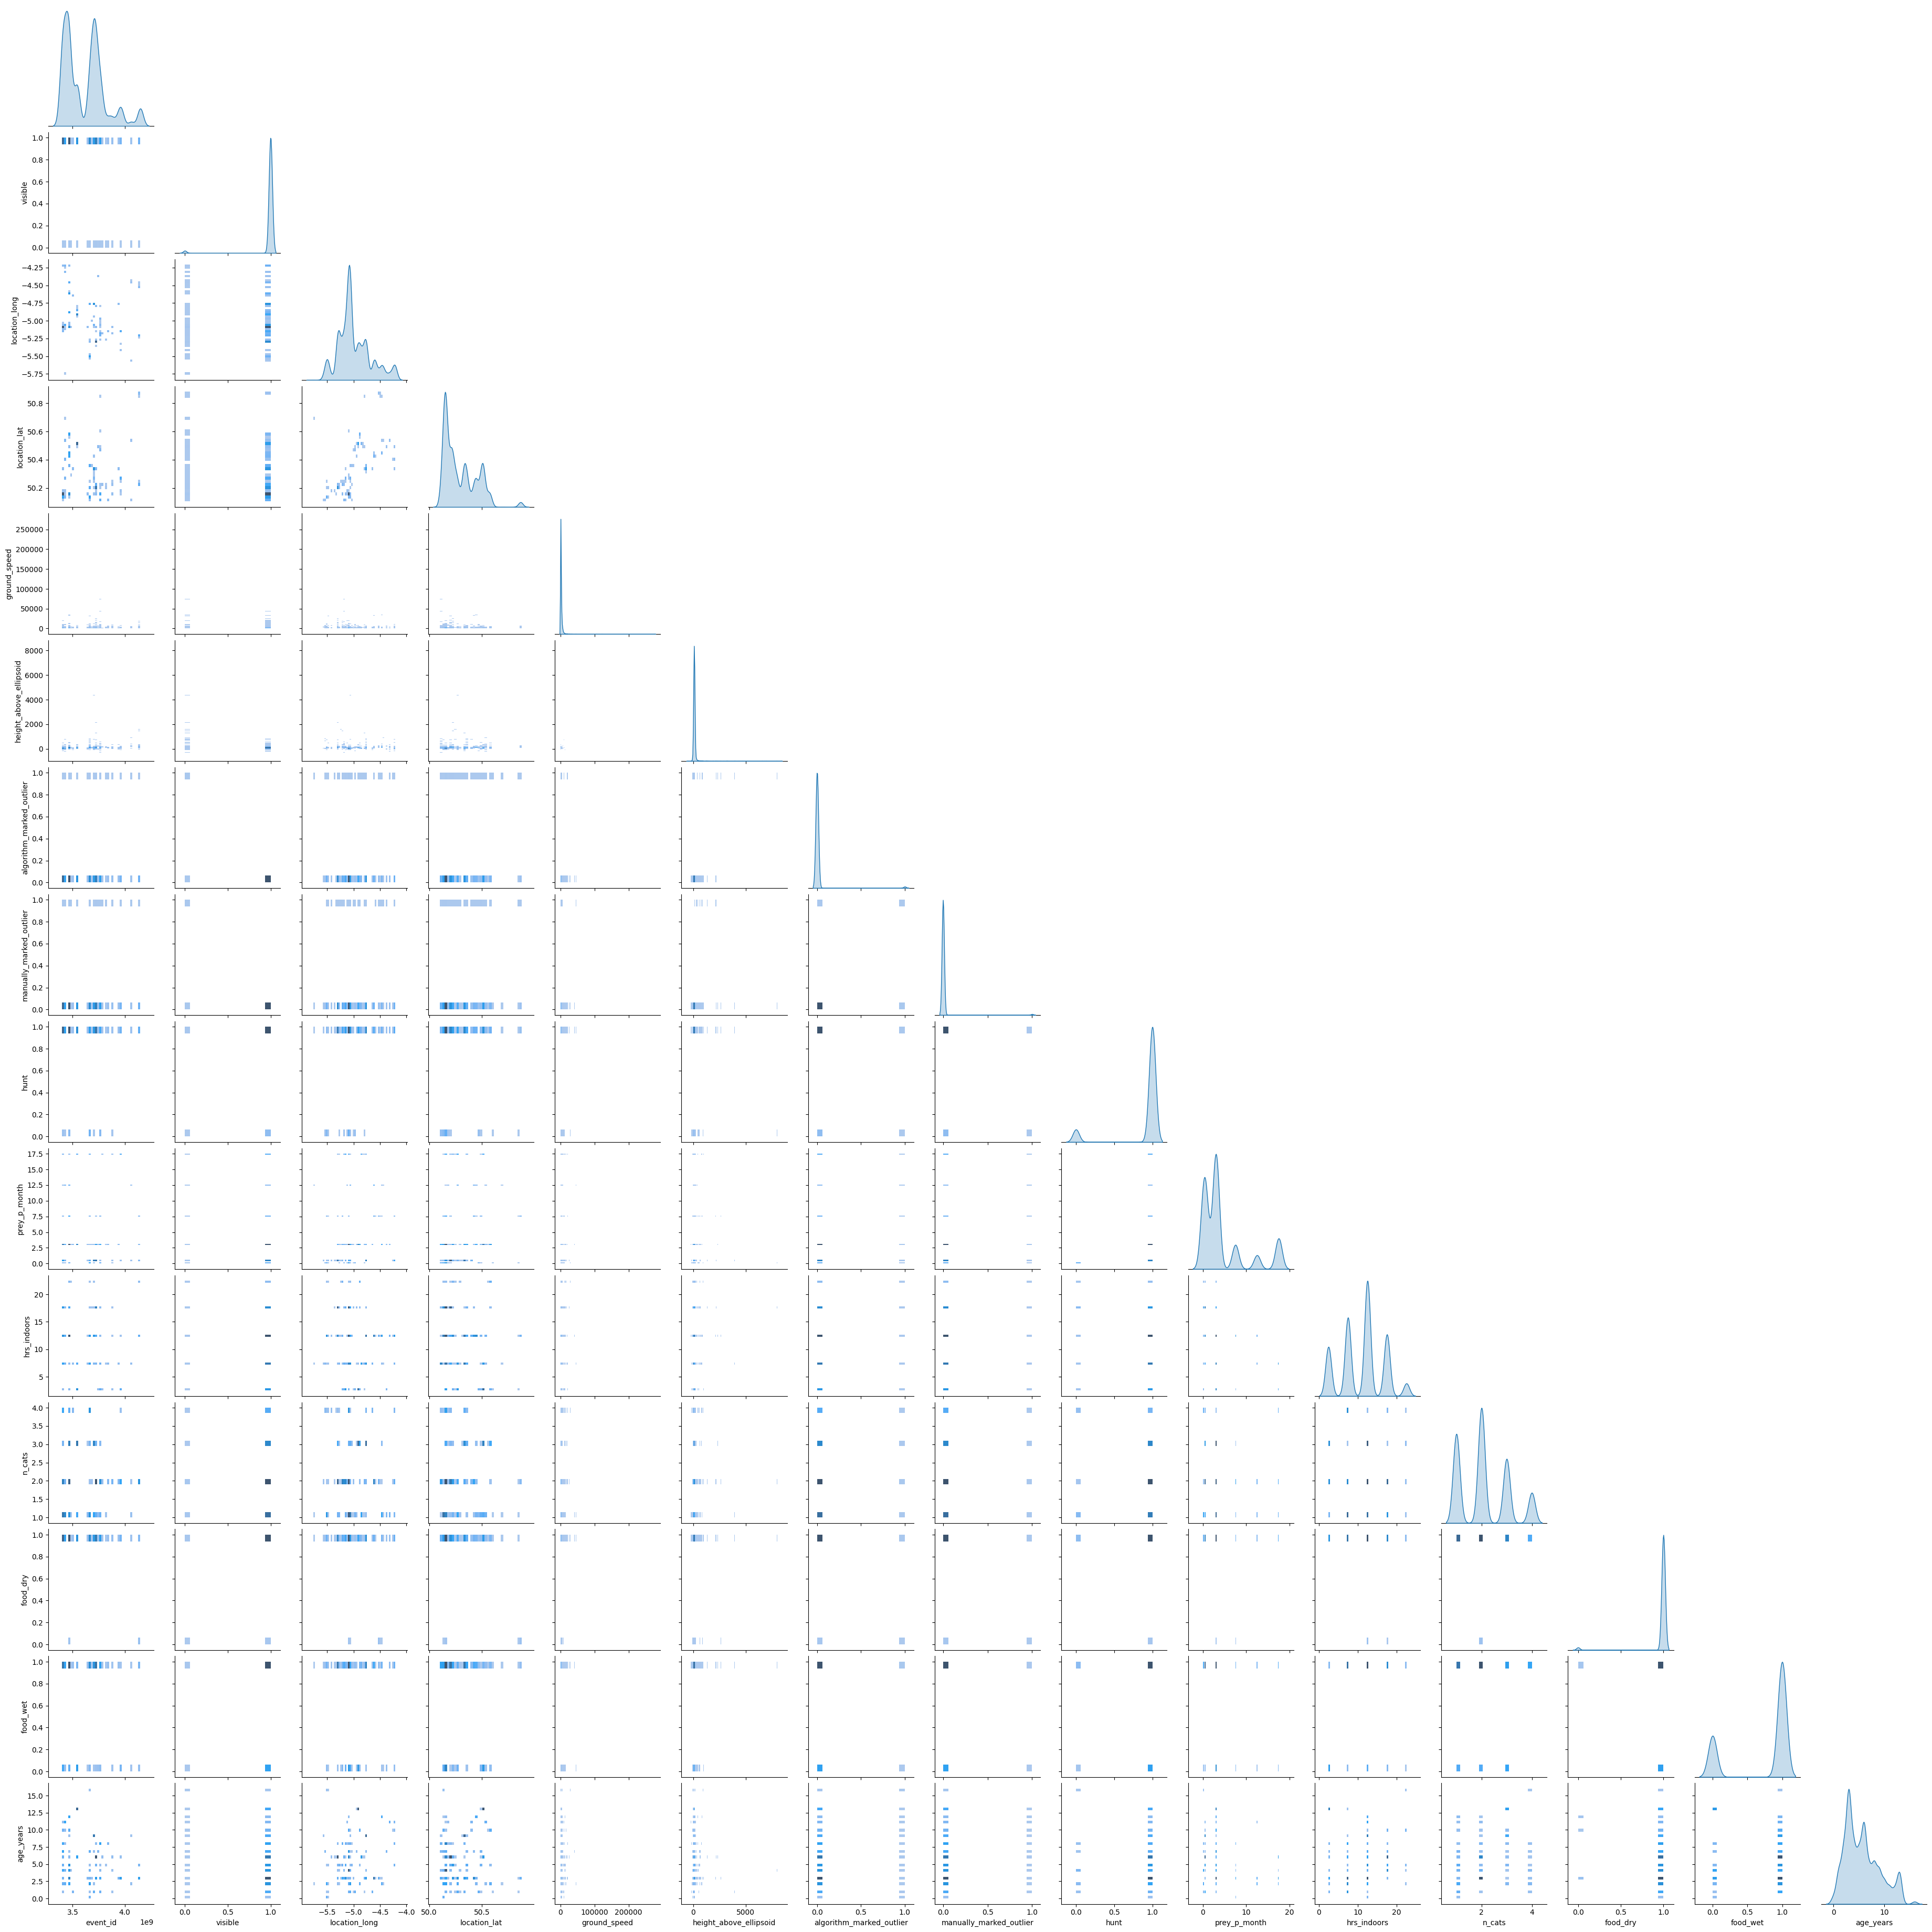

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(cleaned_cats_data, kind="hist", diag_kind="kde", corner=True)

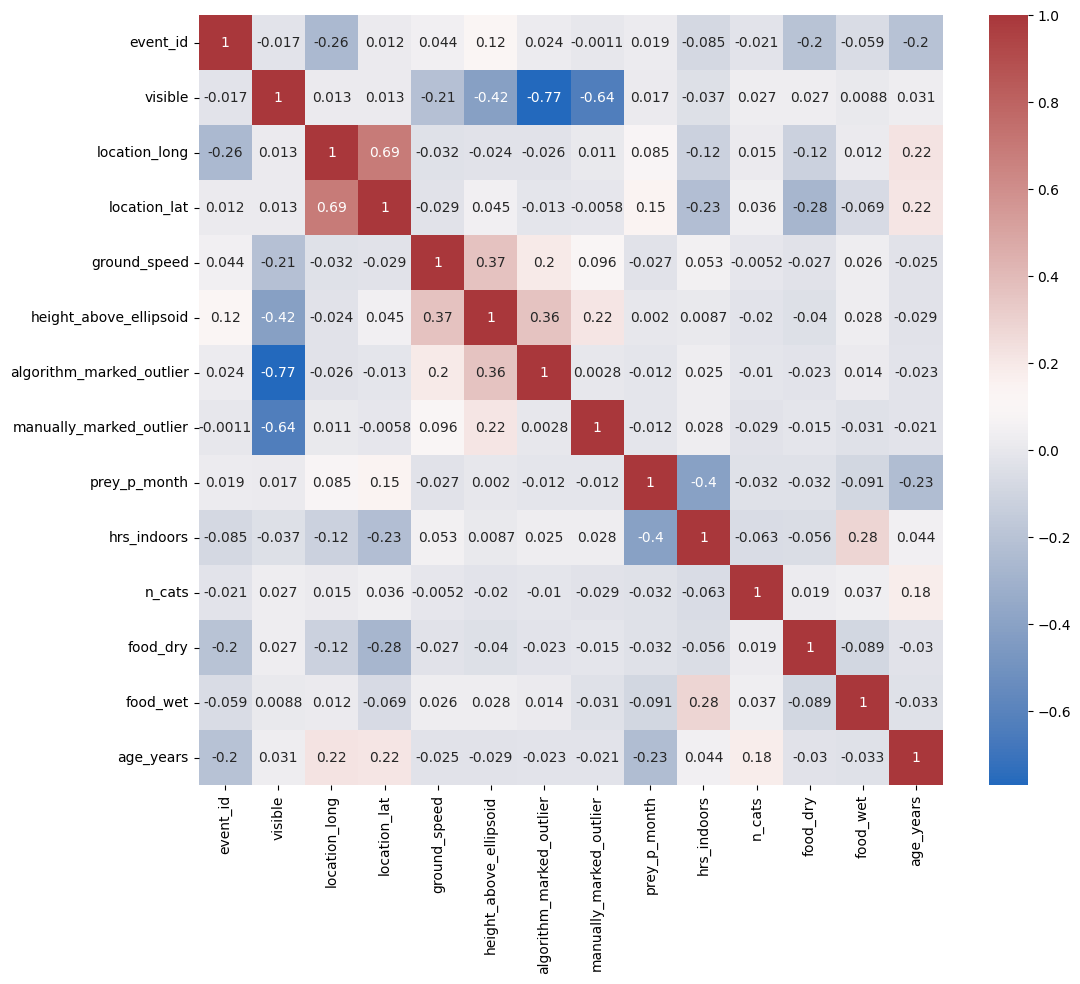

In [ ]:
corr = cleaned_cats_data.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
corr = cleaned_cats_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")
plt.show()

The EDA presented above is inherited from Milestone 1 (M1). As it serves as the shared analytical foundation for all subsequent individual analyses, it has been retained without modification to ensure methodological consistency across team members’ work.

## Integrated Pipeline

In [ ]:
# 1) Converts timestamps to UTC datetime and creates time-of-day indicators.
if "timestamp" in cleaned_cats_data.columns:
    cleaned_cats_data["timestamp"] = pd.to_datetime(cleaned_cats_data["timestamp"], errors="coerce", utc=True)
    cleaned_cats_data = cleaned_cats_data.dropna(subset=["timestamp"])
    cleaned_cats_data["hour"] = cleaned_cats_data["timestamp"].dt.hour
    NIGHT_HOURS = [20,21,22,23,0,1,2,3,4,5]
    cleaned_cats_data["is_night"] = cleaned_cats_data["hour"].isin(NIGHT_HOURS).astype(int)

In [ ]:
# 2) Define cat-level
agg_dict = {}

for col in ["location_lat", "location_long"]:
    if col in cleaned_cats_data.columns:
        agg_dict[col] = ["mean", "std"]

if "ground_speed" in cleaned_cats_data.columns:
    cleaned_cats_data["ground_speed"] = pd.to_numeric(cleaned_cats_data["ground_speed"], errors="coerce")
    cleaned_cats_data = cleaned_cats_data.dropna(subset=["ground_speed"])
    agg_dict["ground_speed"] = ["mean", "std", "max", "median", "count"]

if "height_above_ellipsoid" in cleaned_cats_data.columns:
    agg_dict["height_above_ellipsoid"] = ["mean", "std"]

# night_ratio
if "is_night" in cleaned_cats_data.columns:
    agg_dict["is_night"] = ["mean"]

cat_level = cleaned_cats_data.groupby("tag_id").agg(agg_dict)
cat_level.columns = ["_".join([c for c in col if c]) for col in cat_level.columns]
cat_level = cat_level.reset_index()

# rename for readability
cat_level = cat_level.rename(columns={
    "ground_speed_count": "n_points",
    "is_night_mean": "night_ratio"
})

print("cat_level shape:", cat_level.shape)
cat_level.head()

cat_level shape: (88, 13)


,tag_id,location_lat_mean,location_lat_std,location_long_mean,location_long_std,ground_speed_mean,ground_speed_std,ground_speed_max,ground_speed_median,n_points,height_above_ellipsoid_mean,height_above_ellipsoid_std,night_ratio
0,Abba-Tag,50.163311,0.000407,-5.204463,0.001146,1603.951807,2149.160017,13968,864.0,83,177.981566,195.673112,0.614458
1,Alfie-Tag,50.344323,0.000870,-4.759988,0.001753,1931.679144,2413.262206,14652,1188.0,187,82.725668,102.561322,0.481283
2,Athena,50.170166,0.000247,-5.114081,0.000416,2134.188679,2685.603928,19728,1494.0,106,87.520283,44.317564,0.490566
3,Balu-Tag,50.496850,0.000371,-4.377609,0.000644,2004.957055,3201.522966,31140,1260.0,163,162.257055,45.532426,0.822086
4,Barney-Tag,50.406121,0.000408,-4.232356,0.000461,1646.709677,1775.056549,10548,1188.0,155,42.765806,31.022332,0.522581


In [ ]:
# 3) Merge explanatory variables

meta_cols = ["tag_id"]
for c in ["animal_sex", "hrs_indoors", "hunt", "prey_p_month", "n_cats"]:
    if c in cats_meta.columns:
        meta_cols.append(c)

meta = cats_meta[meta_cols].drop_duplicates("tag_id")
cat_level = cat_level.merge(meta, on="tag_id", how="left")

print("cat_level after meta merge:", cat_level.shape)
cat_level.head()


cat_level after meta merge: (88, 18)


,tag_id,location_lat_mean,location_lat_std,location_long_mean,location_long_std,ground_speed_mean,ground_speed_std,ground_speed_max,ground_speed_median,n_points,height_above_ellipsoid_mean,height_above_ellipsoid_std,night_ratio,animal_sex,hrs_indoors,hunt,prey_p_month,n_cats
0,Abba-Tag,50.163311,0.000407,-5.204463,0.001146,1603.951807,2149.160017,13968,864.0,83,177.981566,195.673112,0.614458,f,7.5,True,3.0,2
1,Alfie-Tag,50.344323,0.000870,-4.759988,0.001753,1931.679144,2413.262206,14652,1188.0,187,82.725668,102.561322,0.481283,m,7.5,True,3.0,2
2,Athena,50.170166,0.000247,-5.114081,0.000416,2134.188679,2685.603928,19728,1494.0,106,87.520283,44.317564,0.490566,f,7.5,True,3.0,2
3,Balu-Tag,50.496850,0.000371,-4.377609,0.000644,2004.957055,3201.522966,31140,1260.0,163,162.257055,45.532426,0.822086,f,2.5,True,3.0,1
4,Barney-Tag,50.406121,0.000408,-4.232356,0.000461,1646.709677,1775.056549,10548,1188.0,155,42.765806,31.022332,0.522581,m,12.5,True,0.5,2


In [ ]:
# 4)Define feature set + impute + scale

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

candidate_features = [
    "location_lat_mean", "location_lat_std",
    "location_long_mean", "location_long_std",
    "ground_speed_mean", "ground_speed_std", "ground_speed_max", "ground_speed_median",
    "height_above_ellipsoid_mean", "height_above_ellipsoid_std",
    "n_points", "night_ratio",
    "hrs_indoors", "prey_p_month", "n_cats"
]

feature_cols = [c for c in candidate_features if c in cat_level.columns]
print("Using features:", feature_cols)

X = cat_level[feature_cols].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imp)

print("X_scaled shape:", X_scaled.shape)

Using features: ['location_lat_mean', 'location_lat_std', 'location_long_mean', 'location_long_std', 'ground_speed_mean', 'ground_speed_std', 'ground_speed_max', 'ground_speed_median', 'height_above_ellipsoid_mean', 'height_above_ellipsoid_std', 'n_points', 'night_ratio', 'hrs_indoors', 'prey_p_month', 'n_cats']
X_scaled shape: (88, 15)


## Unified clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster

k_list = list(range(3, 11))

# KMeans selection
best_k, best_sil, best_model = None, -1, None
k_rows = []
for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    k_rows.append({"k": k, "silhouette": sil, "inertia": km.inertia_})
    if sil > best_sil:
        best_k, best_sil, best_model = k, sil, km

kmeans_eval = pd.DataFrame(k_rows).sort_values("k")
display(kmeans_eval)
print("Best KMeans:", best_k, "sil:", round(best_sil, 4))

labels_km = best_model.fit_predict(X_scaled)

,k,silhouette,inertia
0,3,0.167498,965.426792
1,4,0.180331,845.416690
2,5,0.175865,748.639363
3,6,0.189048,680.666762
4,7,0.186871,632.403485
5,8,0.105220,600.547308
6,9,0.115170,556.557035
7,10,0.156148,520.240693


Best KMeans: 6 sil: 0.189


In [ ]:
# Hierarchical selection
Z = linkage(X_scaled, method="ward")
best_k_h, best_sil_h, best_labels_h = None, -1, None
h_rows = []
for k in k_list:
    labels_h = fcluster(Z, t=k, criterion="maxclust")
    sil_h = silhouette_score(X_scaled, labels_h)
    h_rows.append({"k": k, "silhouette": sil_h})
    if sil_h > best_sil_h:
        best_k_h, best_sil_h, best_labels_h = k, sil_h, labels_h

hier_eval = pd.DataFrame(h_rows).sort_values("k")
display(hier_eval)
print("Best Hier:", best_k_h, "sil:", round(best_sil_h, 4))

,k,silhouette
0,3,0.311252
1,4,0.179182
2,5,0.190344
3,6,0.200794
4,7,0.199492
5,8,0.206877
6,9,0.202251
7,10,0.121169


Best Hier: 3 sil: 0.3113


In [ ]:
ari = adjusted_rand_score(labels_km, best_labels_h)
print("ARI(KMeans vs Hier):", round(ari, 4))

ARI(KMeans vs Hier): 0.2971


In [ ]:
cat_level["cluster_final"] = labels_km
cat_level["cluster_h"] = best_labels_h
cat_level["cluster_final"].value_counts().sort_index()


,count
cluster_final,
0,21
1,43
2,9
3,10
4,3
5,2


##Domain / Business Questions

###Question 1

 **Q1 (Refined)**: Do geographic clusters derived from latitude and longitude represent meaningful differences in behavioral intensity, or are they primarily reflecting spatial density without distinct behavioral structure?

**Explain**: In M2, clustering relied only on latitude and longitude, resulting in limited behavioral differentiation and one dominant cluster. Influenced by Kaixin’s M2, which emphasized cat-level behavioral aggregation, M3 shifts the focus from identifying spatial groups to examining whether geographic clustering truly reflects distinct behavior or simply uneven activity density.

**Significance**:

This analysis is important for understanding cats’ living conditions and spatial distribution across urban areas. Policymakers and city councils can use these insights to develop more effective and region-specific animal control policies. Biodiversity conservation groups can also leverage this information to guide member allocation and resource deployment.



In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

geo_cols = [c for c in ["location_lat_mean", "location_long_mean"] if c in cat_level.columns]
print("Geo columns:", geo_cols)

X_geo = cat_level[geo_cols].copy()
X_geo_scaled = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(X_geo))

k_list = list(range(3, 8))

# KMeans
rows = []
best_k, best_sil = None, -1
best_labels_geo = None

for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_geo_scaled)
    sil = silhouette_score(X_geo_scaled, labels)
    rows.append({"method":"kmeans","k":k,"silhouette":sil})
    if sil > best_sil:
        best_k, best_sil, best_labels_geo = k, sil, labels

# Hierarchical
Z_geo = linkage(X_geo_scaled, method="ward")
for k in k_list:
    labels_h = fcluster(Z_geo, t=k, criterion="maxclust")
    sil_h = silhouette_score(X_geo_scaled, labels_h)
    rows.append({"method":"hier","k":k,"silhouette":sil_h})

eval_geo = pd.DataFrame(rows).sort_values(["method","k"])
display(eval_geo)

cat_level["geo_cluster"] = best_labels_geo
print("Best geo kmeans k:", best_k, "sil:", round(best_sil,4))

# Compare geo-only vs integrated structure
ari_geo_vs_integrated = adjusted_rand_score(cat_level["cluster_final"], cat_level["geo_cluster"])
print("ARI(geo_cluster vs cluster_final):", round(ari_geo_vs_integrated, 4))

# Behavior differences across geo clusters
profile_cols = [c for c in ["ground_speed_mean","ground_speed_max","night_ratio","hrs_indoors","prey_p_month"] if c in cat_level.columns]
geo_profile = cat_level.groupby("geo_cluster")[profile_cols].median().round(2)
display(geo_profile)


Geo columns: ['location_lat_mean', 'location_long_mean']


,method,k,silhouette
5,hier,3,0.563714
6,hier,4,0.553635
7,hier,5,0.562340
8,hier,6,0.569485
9,hier,7,0.623796
0,kmeans,3,0.614738
1,kmeans,4,0.542442
2,kmeans,5,0.562586
3,kmeans,6,0.569904
4,kmeans,7,0.630338


Best geo kmeans k: 7 sil: 0.6303
ARI(geo_cluster vs cluster_final): 0.2187


,ground_speed_mean,ground_speed_max,night_ratio,hrs_indoors,prey_p_month
geo_cluster,,,,,
0,1777.17,14652.0,0.48,12.5,3.0
1,1990.49,19620.0,0.60,12.5,3.0
2,1789.94,14868.0,0.56,12.5,3.0
3,2111.23,18180.0,0.51,12.5,0.5
4,1759.02,20808.0,0.67,7.5,3.0
5,1960.76,17748.0,0.49,12.5,3.0
6,3146.20,62568.0,0.39,12.5,7.5


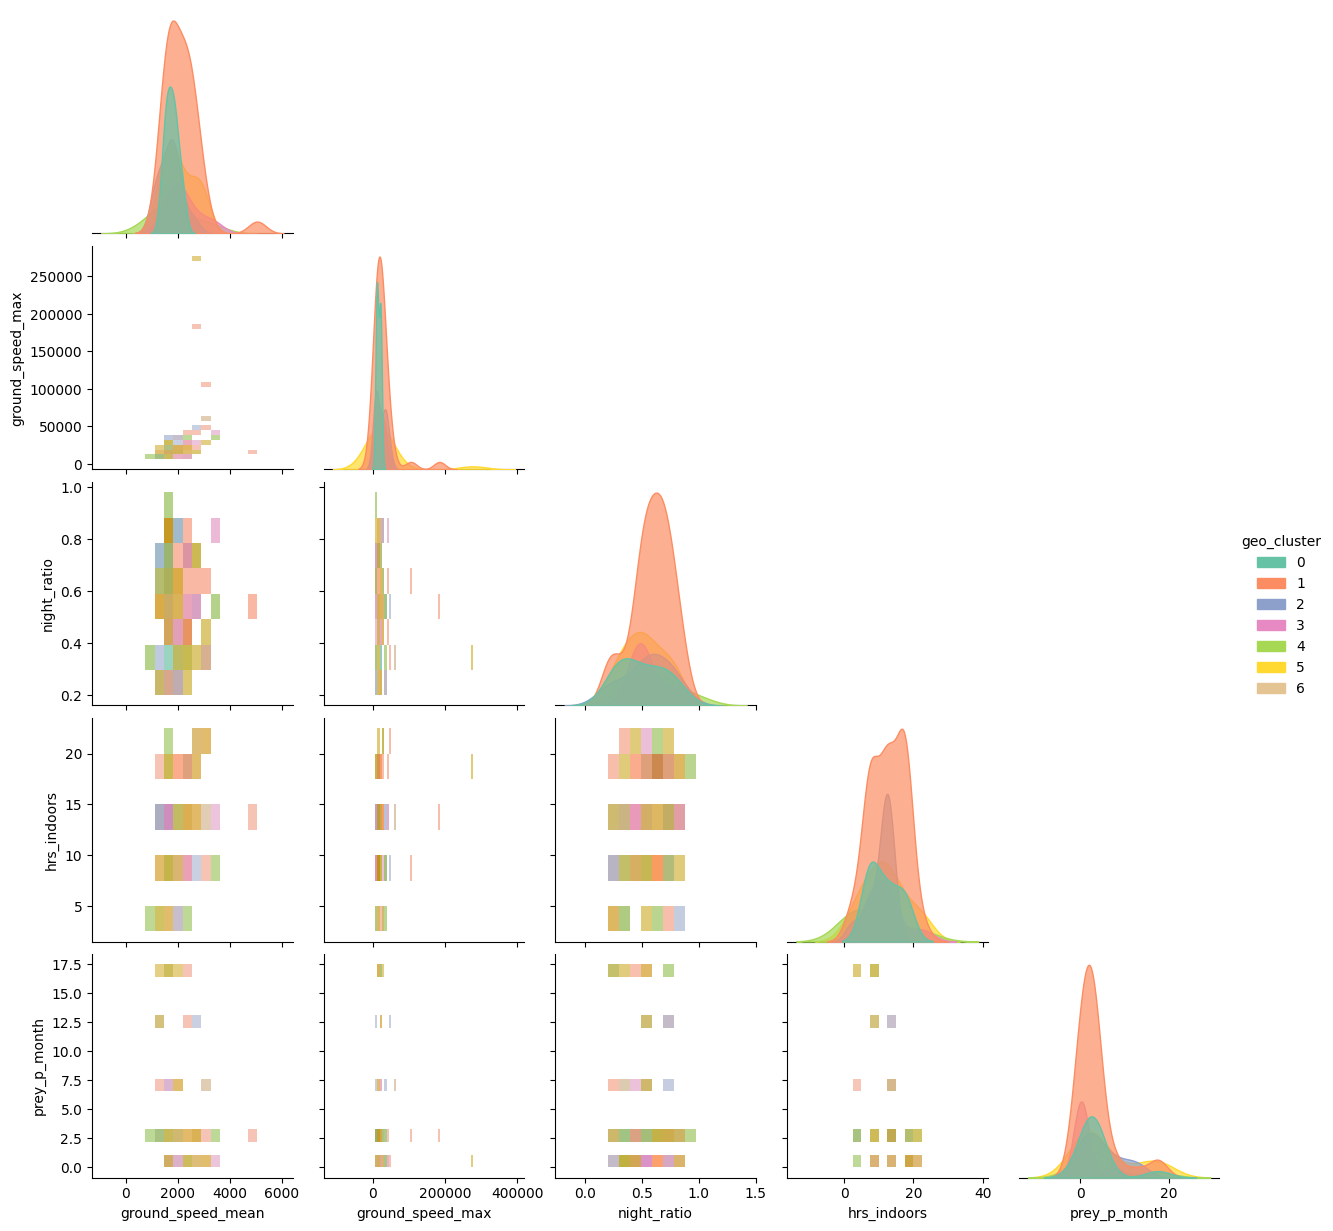

In [ ]:
import seaborn as sns
sns.pairplot(
    cat_level[profile_cols+ ["geo_cluster"]],
    hue="geo_cluster",
    kind="hist",
    diag_kind="kde",
    corner=True,
    palette="Set2",
    plot_kws={'alpha': 0.7},
    diag_kws={'alpha': 0.7}
)


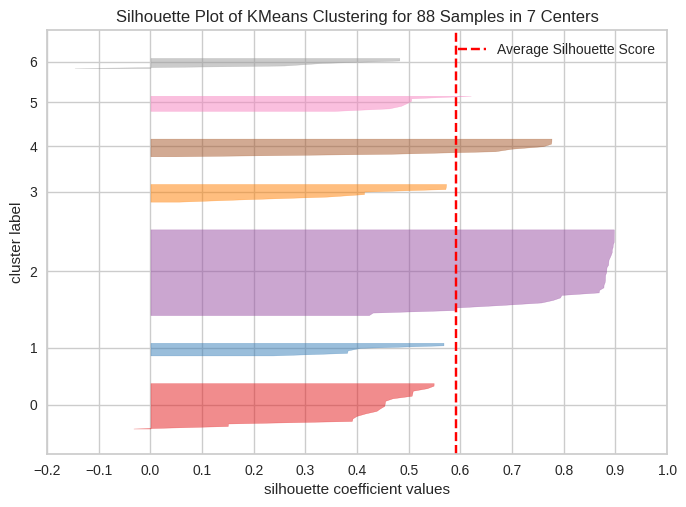

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 88 Samples in 7 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [107]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(best_k, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_geo_scaled)
visualizer.show()

###Question 2

**Q2 (Refined)**: When location and activity-time data are combined, do clearer behavioral groups emerge that help us understand outdoor risk?

**Explain**:  In M2, I analyzed temporal activity patterns while Kang examined spatial areas. Studied separately, spatial patterns were clear and temporal features explained behavioral differences. We refined the question to test whether combining both dimensions produces clearer clusters and improves interpretation of outdoor risk exposure.

**Significance**:

Understanding the daily activity patterns of cats provides valuable insights for researchers studying behavioral traits and the influence of environmental factors on living habits. From a policy perspective, city governments can use this temporal information to design targeted, time-based management strategies aimed at reducing animal-related damage and improving urban coexistence.


In [ ]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

q2_candidate_features = [
    "night_ratio",
    "ground_speed_mean",
    "ground_speed_std",
    "ground_speed_max",
    "ground_speed_median",
    "n_points",
    "hrs_indoors"
]

q2_features = [c for c in q2_candidate_features if c in cat_level.columns]
print("Q2 features used:", q2_features)

X_q2 = cat_level[q2_features].copy()

imputer_q2 = SimpleImputer(strategy="median")
scaler_q2 = StandardScaler()

X_q2_scaled = scaler_q2.fit_transform(imputer_q2.fit_transform(X_q2))
print("X_q2_scaled shape:", X_q2_scaled.shape)


Q2 features used: ['night_ratio', 'ground_speed_mean', 'ground_speed_std', 'ground_speed_max', 'ground_speed_median', 'n_points', 'hrs_indoors']
X_q2_scaled shape: (88, 7)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_list = list(range(3, 9))

q2_rows = []
q2_best_k, q2_best_sil, q2_best_model = None, -1, None

for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_q2_scaled)
    sil = silhouette_score(X_q2_scaled, labels)
    q2_rows.append({"k": k, "silhouette": sil, "inertia": km.inertia_})
    if sil > q2_best_sil:
        q2_best_k, q2_best_sil, q2_best_model = k, sil, km

q2_kmeans_eval = pd.DataFrame(q2_rows).sort_values("k")
display(q2_kmeans_eval)
print("Q2 Best KMeans k =", q2_best_k, "| silhouette =", round(q2_best_sil, 4))

q2_best_labels_km = q2_best_model.fit_predict(X_q2_scaled)
cat_level["cluster_q2"] = q2_best_labels_km
cat_level["cluster_q2"].value_counts().sort_index()


,k,silhouette,inertia
0,3,0.211700,366.729039
1,4,0.199351,303.629982
2,5,0.204682,261.931521
3,6,0.220687,228.585963
4,7,0.211668,202.642357
5,8,0.239570,171.705308


Q2 Best KMeans k = 8 | silhouette = 0.2396


,count
cluster_q2,
0,11
1,28
2,2
3,29
4,1
5,14
6,1
7,2


In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import adjusted_rand_score

Z_q2 = linkage(X_q2_scaled, method="ward")

q2_labels_h = fcluster(Z_q2, t=q2_best_k, criterion="maxclust")

q2_ari = adjusted_rand_score(cat_level["cluster_q2"], q2_labels_h)
print("Q2 ARI(KMeans vs Hier @same k):", round(q2_ari, 4))

cat_level["cluster_q2_h"] = q2_labels_h


Q2 ARI(KMeans vs Hier @same k): 0.4753


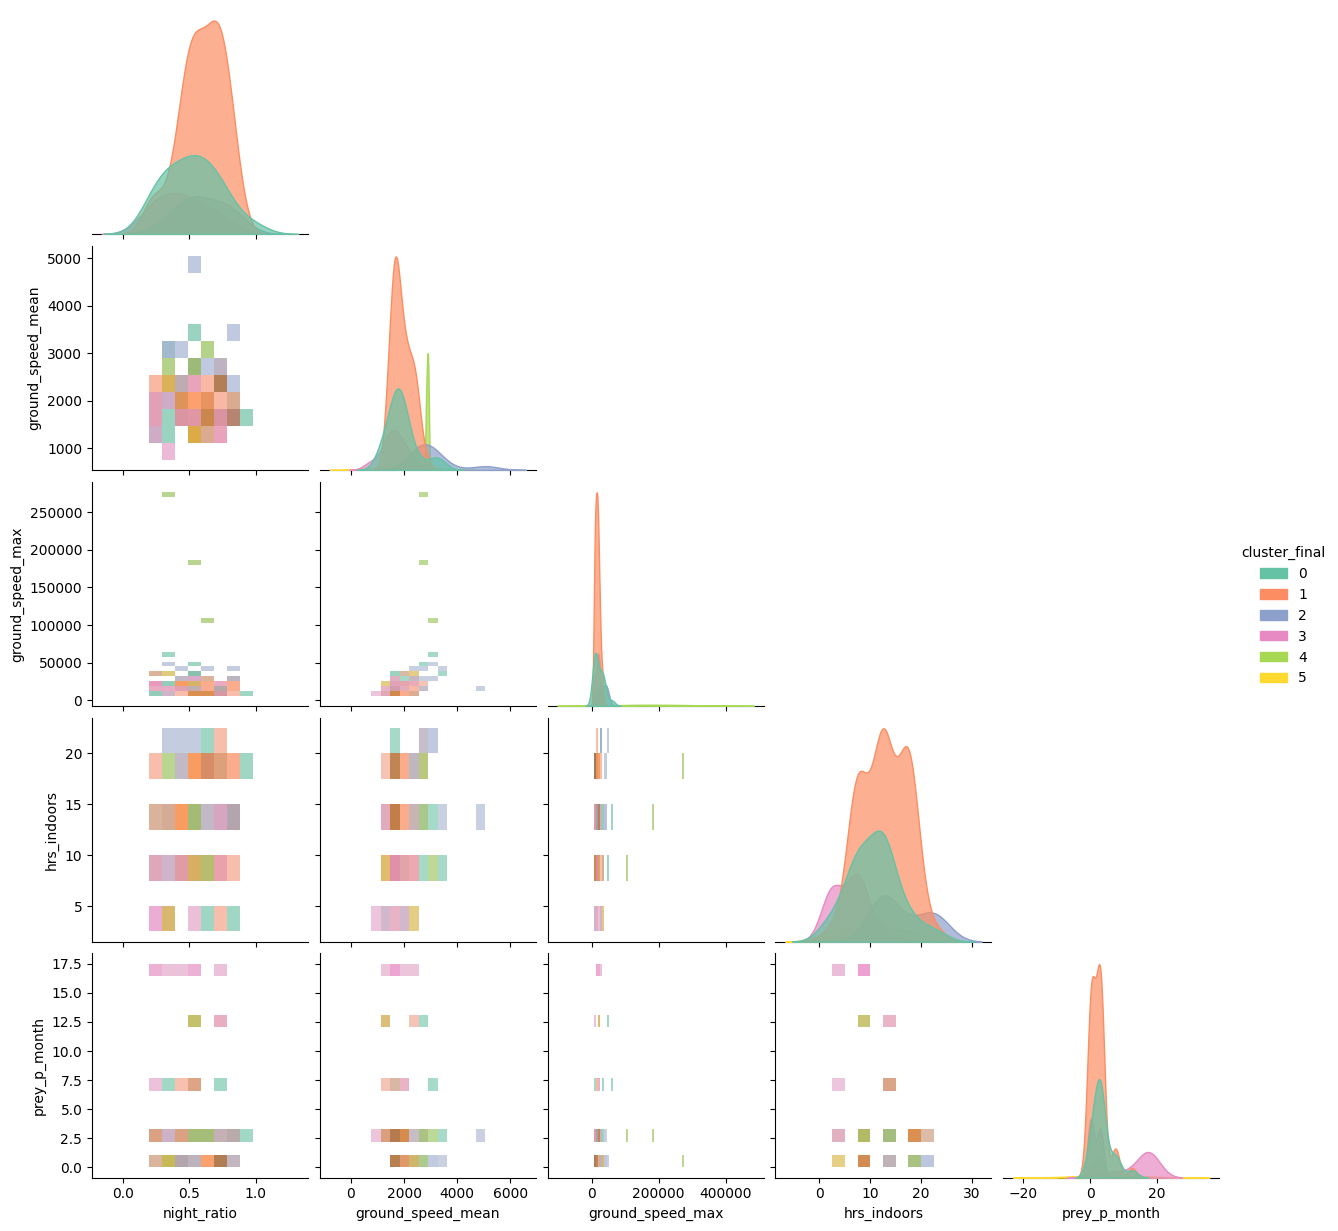

In [ ]:
q2_vars = [
    "night_ratio",
    "ground_speed_mean",
    "ground_speed_max",
    "hrs_indoors",
    "prey_p_month"
]

q2_vars = [v for v in q2_vars]

sns.pairplot(
    cat_level[q2_vars + ["cluster_final"]],
    hue="cluster_final",
    kind="hist",
    diag_kind="kde",
    corner=True,
    palette="Set2",
    plot_kws={'alpha': 0.7},
    diag_kws={'alpha': 0.7}
)


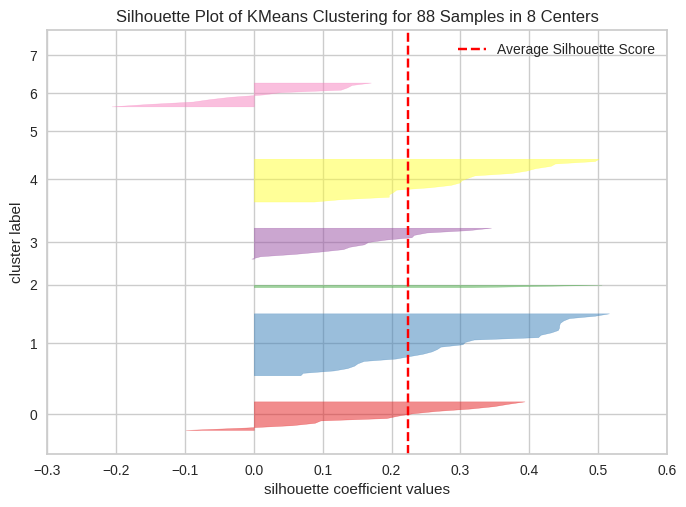

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 88 Samples in 8 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [108]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(q2_best_k, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_q2_scaled)
visualizer.show()

###Question 3

**Q3** (Refined): Does gender influence key behavioral patterns—such as indoor time and prey captured per month—within behavioral clusters, even if spatial patterns remain similar?

 **Explain**: Clustering results show no strong relationship between gender and spatial location. However, Han’s Q4 inspired a deeper look at behavioral traits. Gender may influence prey capture and indoor hours, which are important for biodiversity protection. This direction may generate more meaningful stakeholder insights.

**Significance**:

Understanding whether male and female cats actually follow different spatial and living patterns, or whether they mostly share the same patterns but appear in different proportions, is important for correctly interpreting urban cat behavior. This distinction helps avoid overly simple gender-based conclusions and provides clearer context for adoption decisions and welfare considerations.

In [ ]:
# Distribution by gender across the SAME underlying clusters
ct = pd.crosstab(cat_level['animal_sex'], cat_level['cluster_h'], normalize='index')
ct

cluster_h,1,2,3
animal_sex,,,
f,0.815789,0.026316,0.157895
m,0.860000,0.020000,0.120000


In [ ]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(ct: pd.DataFrame):
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    v = np.sqrt((chi2 / n) / (min(r-1, k-1) + 1e-12))
    return v, p

ct = pd.crosstab(cat_level["animal_sex"], cat_level["cluster_final"])
ct_norm = pd.crosstab(cat_level["animal_sex"], cat_level["cluster_final"], normalize='index')
v, p = cramers_v(ct)

print("Sex x Cluster (counts):")
display(ct)
print("Sex x Cluster (row %):")
display(ct_norm.round(3))
print("Cramer's V:", round(v, 3), "p-value:", p)


Sex x Cluster (counts):


cluster_final,0,1,2,3,4,5
animal_sex,,,,,,
f,10,16,4,5,2,1
m,11,27,5,5,1,1


Sex x Cluster (row %):


cluster_final,0,1,2,3,4,5
animal_sex,,,,,,
f,0.263,0.421,0.105,0.132,0.053,0.026
m,0.220,0.540,0.100,0.100,0.020,0.020


Cramer's V: 0.139 p-value: 0.8887373424126769


In [ ]:
if p < 0.05:
    conclusion = (
        "Gender is associated with different distributions across the SAME spatial–lifestyle clusters "
        "(i.e., shared underlying structure with different allocations)."
    )
else:
    conclusion = (
        "We do not find strong evidence that gender shifts the distribution across the underlying spatial–lifestyle clusters."
    )

conclusion


'We do not find strong evidence that gender shifts the distribution across the underlying spatial–lifestyle clusters.'

In [116]:

k_list = (range(3, 9))

q3_rows = []
q3_best_k, q3_best_sil, q3_best_model = None, -1, None

for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    q3_rows.append({"k": k, "silhouette": sil, "inertia": km.inertia_})
    if sil > q3_best_sil:
        q3_best_k, q3_best_sil, q3_best_model = k, sil, km

q3_kmeans_eval = pd.DataFrame(q3_rows).sort_values("k")
display(q3_kmeans_eval)
print("Q3 Best KMeans k =", q3_best_k, "| silhouette =", round(q3_best_sil, 4))

cat_level["cluster_q3"] = q3_best_model.fit_predict(X_scaled)
cat_level["cluster_q3"].value_counts().sort_index()


,k,silhouette,inertia
0,3,0.167498,965.426792
1,4,0.180331,845.416690
2,5,0.175865,748.639363
3,6,0.189048,680.666762
4,7,0.186871,632.403485
5,8,0.105220,600.547308


Q3 Best KMeans k = 6 | silhouette = 0.189


,count
cluster_q3,
0,21
1,43
2,9
3,10
4,3
5,2


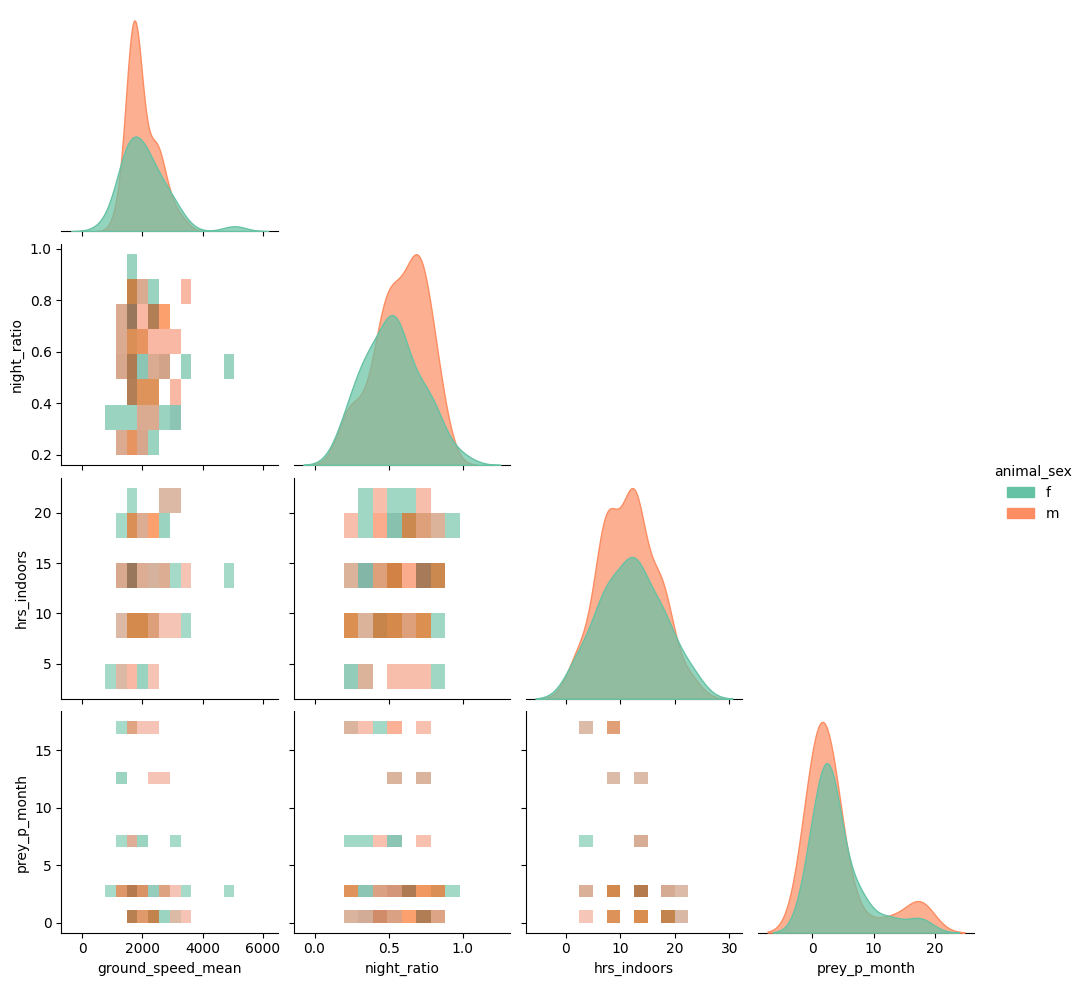

In [ ]:
q3_vars = [
    "ground_speed_mean",
    "night_ratio",
    "hrs_indoors",
    "prey_p_month"
]

q3_vars = [v for v in q3_vars]

sns.pairplot(
    cat_level[q3_vars + ["animal_sex"]],
    hue="animal_sex",
    kind="hist",
    diag_kind="kde",
    corner=True,
    palette="Set2",
    plot_kws={'alpha': 0.7},
    diag_kws={'alpha': 0.7}
)


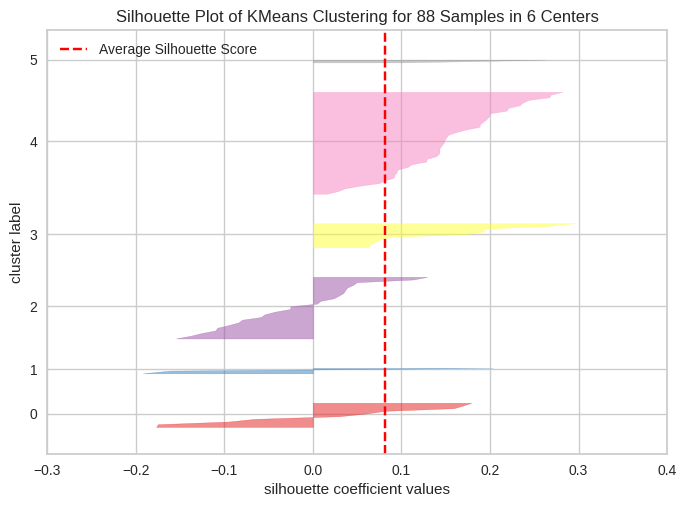

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 88 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [117]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(q3_best_k, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_scaled)
visualizer.show()

###Question 4

**Q4 (Newly Refined)**: How can unsupervised learning identify spatial and behavioral clusters, and how does feeding type vary across them in relation to hunting and environmental exposure?
**Explain:** In M2, I found feeding type had limited impact on cluster formation; behavioral patterns and location were stronger drivers. After reviewing Kang’s Q1, which also showed one large cluster and several smaller ones, I reconsidered whether feeding type might relate more to location than overall behavior. This refined direction clarifies what feeding type may actually influence.


**significance**:

This analyzes the Information on feeding food types can help government animal control agencies and pet owners better understand how feeding behaviors influence cats’ living patterns. These insights can also support animal shelters and pet owners in selecting appropriate food types to protect biodiversity and ecological systems while improving interactions between cats and humans.


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

q4_candidate_features = [
    "hrs_indoors",
    "hunt",
    "prey_p_month",
    "n_cats",
    "night_ratio"
]

q4_features = [c for c in q4_candidate_features if c in cat_level.columns]
print("Q4-A features used:", q4_features)

X_q4 = cat_level[q4_features].copy()

imputer_q4 = SimpleImputer(strategy="median")
scaler_q4 = StandardScaler()

X_q4_scaled = scaler_q4.fit_transform(imputer_q4.fit_transform(X_q4))
print("X_q4_scaled shape:", X_q4_scaled.shape)


Q4-A features used: ['hrs_indoors', 'hunt', 'prey_p_month', 'n_cats', 'night_ratio']
X_q4_scaled shape: (88, 5)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_list = list(range(3, 9))

q4_rows = []
q4_best_k, q4_best_sil, q4_best_model = None, -1, None

for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_q4_scaled)
    sil = silhouette_score(X_q4_scaled, labels)
    q4_rows.append({"k": k, "silhouette": sil, "inertia": km.inertia_})
    if sil > q4_best_sil:
        q4_best_k, q4_best_sil, q4_best_model = k, sil, km

q4_kmeans_eval = pd.DataFrame(q4_rows).sort_values("k")
display(q4_kmeans_eval)
print("Q4-A Best KMeans k =", q4_best_k, "| silhouette =", round(q4_best_sil, 4))

q4_best_labels_km = q4_best_model.fit_predict(X_q4_scaled)
cat_level["cluster_q4"] = q4_best_labels_km
cat_level["cluster_q4"].value_counts().sort_index()


,k,silhouette,inertia
0,3,0.345483,262.574990
1,4,0.248498,212.330119
2,5,0.234653,186.296713
3,6,0.245312,167.005064
4,7,0.246218,147.707514
5,8,0.280148,129.000897


Q4-A Best KMeans k = 3 | silhouette = 0.3455


,count
cluster_q4,
0,65
1,11
2,12


In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import adjusted_rand_score

Z_q4 = linkage(X_q4_scaled, method="ward")
q4_labels_h = fcluster(Z_q4, t=q4_best_k, criterion="maxclust")

q4_ari = adjusted_rand_score(cat_level["cluster_q4"], q4_labels_h)
print("Q4-A ARI(KMeans vs Hier @same k):", round(q4_ari, 4))

cat_level["cluster_q4_h"] = q4_labels_h


Q4-A ARI(KMeans vs Hier @same k): 0.8797


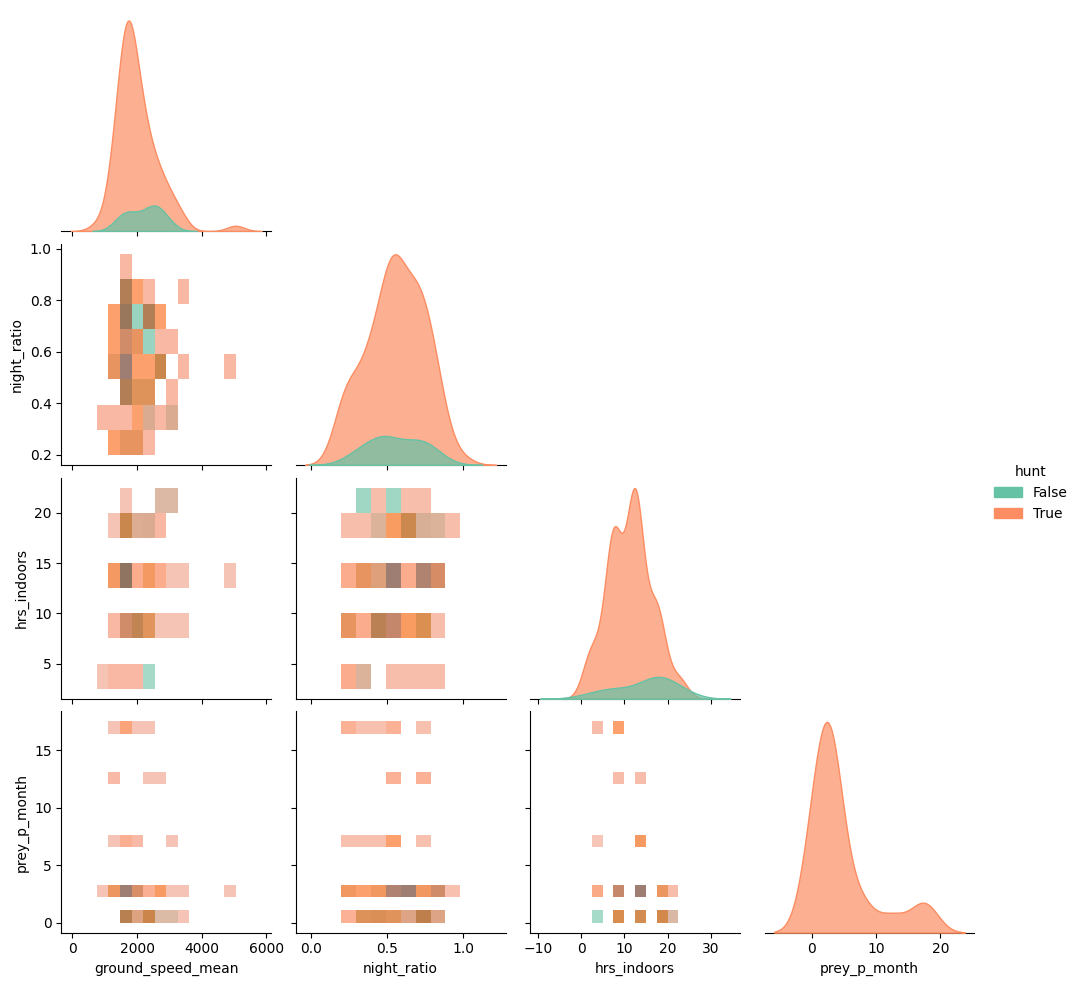

In [ ]:
q4_vars = [
    "ground_speed_mean",
    "night_ratio",
    "hrs_indoors",
    "prey_p_month"
]

q4_vars = [v for v in q4_vars]

sns.pairplot(
    cat_level[q4_vars + ["hunt"]],
    hue="hunt",
    kind="hist",
    diag_kind="kde",
    corner=True,
    palette="Set2",
    plot_kws={'alpha': 0.7},
    diag_kws={'alpha': 0.7}
)


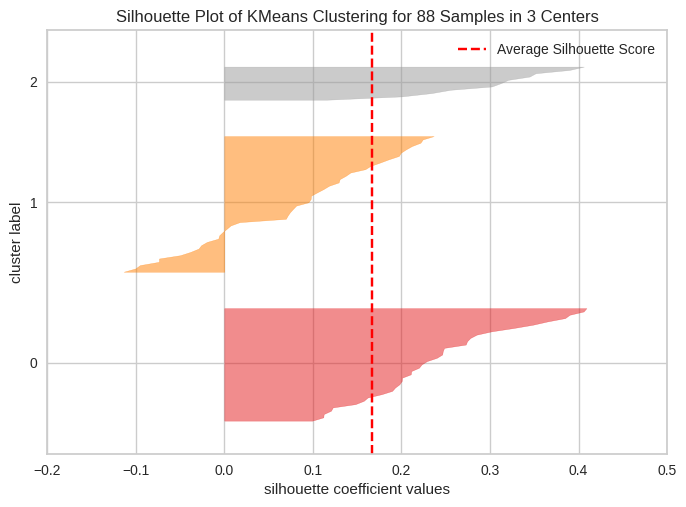

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 88 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [109]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(q4_best_k, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_q4_scaled)
visualizer.show()

## AI Disclosure





*   Add Comments
*   Coding Aid (part)
*   Text Revision
*   Grammar Check
*   Project Initial Brainstorm
*   Formatting




ChatGPT Link:
https://chatgpt.com/share/699520c9-0174-800e-a0ec-5f6fa0d54137



